In [ ]:
!nvidia-smi

Sun Apr 19 12:25:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              8W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.1 MB/s eta 0:00:00


In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.6/107.7 GB disk)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import yaml

dataset_path = '/content/drive/MyDrive/Models/Ohm-Vision/Datasets/yolo-pose'

data_yaml = {
    'path': dataset_path,
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',

    #Classes
    'nc': 3,
    'names': ['board', 'resistor', 'wire'],

    # kpt_shape: [Max nummber of point, 3]
    'kpt_shape': [4, 3]
}

yaml_path = '/content/drive/MyDrive/Models/Ohm-Vision/Datasets/yolo-pose/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f" Create {yaml_path} file completed!")

 Create /content/drive/MyDrive/Models/Ohm-Vision/Datasets/yolo-pose/data.yaml file completed!


In [ ]:
from ultralytics import YOLO

print(" YOLO-Pose Training...")

model = YOLO('yolov8n-pose.pt')

results = model.train(
    data='/content/drive/MyDrive/Models/Ohm-Vision/Datasets/yolo-pose/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,

    project='/content/drive/MyDrive/Models/Ohm-Vision/YoloPose-Training-Results',
    name='YOLOv8n_1',

    # Yolo augmentation builtin disabled
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    degrees=0.0, translate=0.0, scale=0.0, shear=0.0, perspective=0.0,
    flipud=0.0, fliplr=0.0, mosaic=0.0, mixup=0.0, copy_paste=0.0,
    erasing=0.0, auto_augment=False, crop_fraction=1.0
)
print("Training Completed")

 YOLO-Pose Training...
WARNING ⚠️ 'crop_fraction' is deprecated and will be removed in the future.
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=False, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Models/Ohm-Vision/Datasets/yolo-pose/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-pose.pt, momentum=0.937,

In [ ]:
from ultralytics import YOLO

print("Testing model(Inference)...")

model_path = '/content/drive/MyDrive/Models/Ohm-Vision/YoloPose-Training-Results/YOLOv8n_1/weights/best.pt'
model = YOLO(model_path)

test_image = '/content/drive/MyDrive/Models/Ohm-Vision/Datasets/yolo-pose/images/test/img_047_jpg.rf.edfbb15ea6bf5989d70dd9e61732b91f.jpg'
results = model(test_image, conf=0.5, save=True)

print("✅ Test Completed! Colab will show result in runs/pose/predict")

Testing model(Inference)...

image 1/1 /content/drive/MyDrive/Models/Ohm-Vision/Datasets/yolo-pose/images/test/img_047_jpg.rf.edfbb15ea6bf5989d70dd9e61732b91f.jpg: 640x640 1 board, 4 resistors, 4 wires, 10.6ms
Speed: 3.7ms preprocess, 10.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/pose/predict
✅ Test Completed! Colab will show result in runs/pose/predict


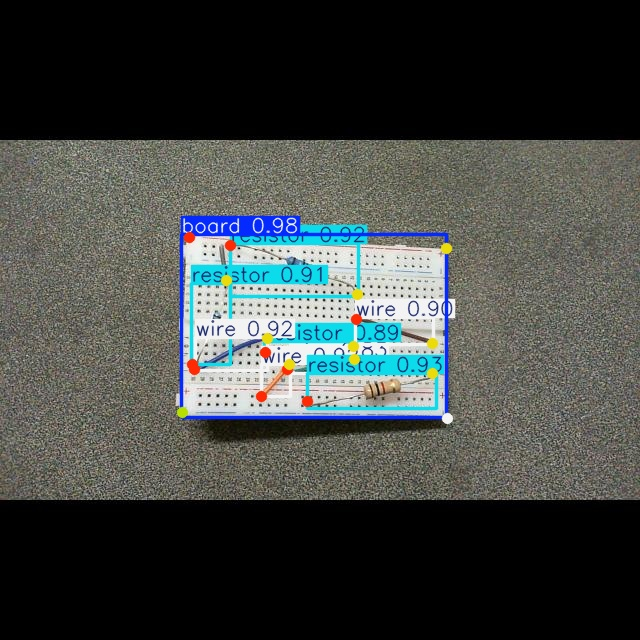

In [ ]:
from IPython.display import Image, display

display(Image(filename='runs/pose/predict/img_047_jpg.rf.edfbb15ea6bf5989d70dd9e61732b91f.jpg'))

In [4]:
import glob
import os

label_dir = "/content/drive/MyDrive/Models/Ohm-Vision/Datasets/yolo-pose/labels/test"
txt_files = glob.glob(os.path.join(label_dir, "*.txt"))

fixed_count = 0

for txt_file in txt_files:
    with open(txt_file, 'r') as f:
        lines = f.readlines()

    new_lines = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 0: continue

        new_parts = [parts[0]] # Class ID

        for i in range(1, len(parts)):
            val = float(parts[i])
            is_visibility_flag = (i - 1) % 3 == 0 and i > 4

            if not is_visibility_flag:
                val = max(0.0, min(1.0, val))
                new_parts.append(f"{val:.4f}")
            else:
                new_parts.append(str(int(val)))

        new_lines.append(" ".join(new_parts) + "\n")

    with open(txt_file, 'w') as f:
        f.writelines(new_lines)
    fixed_count += 1

print(f"Fix Labels file total {fixed_count} files!")

cache_file = os.path.join(label_dir, "test.cache")
if os.path.exists(cache_file):
    os.remove(cache_file)
    print("Remove test.cache completed!")

Fix Labels file total 32 files!


In [7]:
from ultralytics import YOLO

# 1. Load your exported ONNX model
model = YOLO("/content/drive/MyDrive/Models/Ohm-Vision/Yolo_v8n_pose_weights.onnx", task="pose")

# 2. Run validation on the test split
print(" Testing ONNX model on test dataset...")
metrics = model.val(data="/content/drive/MyDrive/Models/Ohm-Vision/Datasets/yolo-pose/data.yaml", split="test")

print("\n" + "="*40)
print("  THE FINAL RESULTS (ONNX TEST SET) ")
print("="*40)

print(f" Box mAP50:      {metrics.box.map50:.4f}")
print(f" Box mAP50-95:   {metrics.box.map:.4f}")

print("-" * 40)

print(f" Pose mAP50:     {metrics.pose.map50:.4f}")
print(f" Pose mAP50-95:  {metrics.pose.map:.4f}")
print("="*40)

 Testing ONNX model on test dataset...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
Loading /content/drive/MyDrive/Models/Ohm-Vision/Yolo_v8n_pose_weights.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CPUExecutionProvider
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 1.9±0.3 ms, read: 9.2±5.5 MB/s, size: 52.1 KB)
val: Scanning /content/drive/MyDrive/Models/Ohm-Vision/Datasets/yolo-pose/labels/test... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 3.5it/s 9.2s
val: New cache created: /content/drive/MyDrive/Models/Ohm-Vision/Datasets/yolo-pose/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 4.5it/s 7.0s
                   all         32        284      0.967      0.957      0.986      0.783      0.934      0.924      0.933      0.912
                 board         32 